In [1]:

!pip install numpy pandas scikit-learn matplotlib seaborn networkx pomegranate


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.7 MB/s eta 0:00:00
  Created wheel for apricot-select: filename=apricot_select-0.6.1-py3-none-any.whl size=48767 sha256=f96207c10f2224aea73209a2b6499390219cdccc73e817d9fdceacbed5f03ef3
  Stored in directory: /root/.cache/pip/wheels/19/ce/18/f10e7debb348bf14d4ab90c8b657a91a79f1106b699a1121c3
Successfully built apricot-select


In [4]:
from google.colab import files
uploaded = files.upload()  # 📂 Select the CSV file from your computer


Saving bbn_disease_symptom_dataset (1).csv to bbn_disease_symptom_dataset (1) (1).csv


In [6]:
import pandas as pd
df = pd.read_csv('bbn_disease_symptom_dataset (1).csv')
df.head()


,Disease,Fever,Cough,Fatigue,LossOfTaste
0,Flu,True,True,True,False
1,Healthy,False,False,False,False
2,Healthy,False,False,False,False
3,Healthy,False,False,False,False
4,Cold,False,True,False,False


In [7]:
# Get basic info about dataset
df.info()

# Summary statistics
df.describe()

# Unique diseases and symptom columns
print("\nDiseases:", df['Disease'].unique())
print("\nColumns:", df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Disease      150 non-null    object
 1   Fever        150 non-null    bool  
 2   Cough        150 non-null    bool  
 3   Fatigue      150 non-null    bool  
 4   LossOfTaste  150 non-null    bool  
dtypes: bool(4), object(1)
memory usage: 1.9+ KB

Diseases: ['Flu' 'Healthy' 'Cold' 'COVID']

Columns: ['Disease', 'Fever', 'Cough', 'Fatigue', 'LossOfTaste']


In [9]:
# Check missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 Disease        0
Fever          0
Cough          0
Fatigue        0
LossOfTaste    0
dtype: int64


In [11]:
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Disease      150 non-null    object
 1   Fever        150 non-null    bool  
 2   Cough        150 non-null    bool  
 3   Fatigue      150 non-null    bool  
 4   LossOfTaste  150 non-null    bool  
dtypes: bool(4), object(1)
memory usage: 1.9+ KB
None
   Disease  Fever  Cough  Fatigue  LossOfTaste
0      Flu   True   True     True        False
1  Healthy  False  False    False        False
2  Healthy  False  False    False        False
3  Healthy  False  False    False        False
4     Cold  False   True    False        False


In [12]:
for col in ['Fever','Cough','Fatigue','LossOfTaste']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [13]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, stratify=df['Disease'], random_state=42)
train.shape, test.shape


((120, 5), (30, 5))

In [14]:
diseases = sorted(train['Disease'].unique())
symptoms = ['Fever','Cough','Fatigue','LossOfTaste']

# 🧠 Priors
priors = train['Disease'].value_counts(normalize=True).to_dict()

# 🧮 CPT with Laplace smoothing
alpha = 1
cpt = {}
for d in diseases:
    sub = train[train['Disease'] == d]
    n = len(sub)
    cpt[d] = {}
    for s in symptoms:
        k = sub[s].sum()
        cpt[d][s] = (k + alpha) / (n + 2*alpha)

print("Priors:\n", priors)
print("\nCPTs:")
pd.DataFrame(cpt).T


Priors:
 {'Healthy': 0.6833333333333333, 'Flu': 0.14166666666666666, 'Cold': 0.125, 'COVID': 0.05}

CPTs:


,Fever,Cough,Fatigue,LossOfTaste
COVID,0.125000,0.125000,0.125000,0.125000
Cold,0.058824,0.058824,0.058824,0.058824
Flu,0.052632,0.052632,0.052632,0.052632
Healthy,0.011905,0.011905,0.011905,0.011905


In [16]:
def posterior(evidence, priors, cpt, diseases):
    scores = {}
    for d in diseases:
        score = priors[d]
        for s, val in evidence.items():
            p_s_given_d = cpt[d][s]
            score *= p_s_given_d if val == 1 else (1 - p_s_given_d)
        scores[d] = score
    total = sum(scores.values())
    for d in scores:
        scores[d] /= total
    return scores


In [17]:
evidence = {'Fever': 1, 'Cough': 1, 'Fatigue': 0, 'LossOfTaste': 0}
posterior(evidence, priors, cpt, diseases)


{'COVID': np.float64(0.41885664927689964),
 'Cold': np.float64(0.2682956124881304),
 'Flu': np.float64(0.24663661970814138),
 'Healthy': np.float64(0.06621111852682866)}

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report

y_true = []
y_pred = []
y_proba = []

for _, row in test.iterrows():
    evidence = {s: row[s] for s in symptoms}
    probs = posterior(evidence, priors, cpt, diseases)
    y_true.append(row['Disease'])
    y_proba.append([probs[d] for d in diseases])
    y_pred.append(max(probs, key=probs.get))

print("✅ Accuracy:", accuracy_score(y_true, y_pred))
print("\n📉 Log Loss:", log_loss(y_true, y_proba, labels=diseases))
print("\n📋 Classification Report:\n", classification_report(y_true, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_true, y_pred, labels=diseases))


✅ Accuracy: 0.7

📉 Log Loss: 0.9034283923461911

📋 Classification Report:
               precision    recall  f1-score   support

       COVID       0.00      0.00      0.00         1
        Cold       0.00      0.00      0.00         4
         Flu       0.00      0.00      0.00         4
     Healthy       0.70      1.00      0.82        21

    accuracy                           0.70        30
   macro avg       0.17      0.25      0.21        30
weighted avg       0.49      0.70      0.58        30


📊 Confusion Matrix:
 [[ 0  0  0  1]
 [ 0  0  0  4]
 [ 0  0  0  4]
 [ 0  0  0 21]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


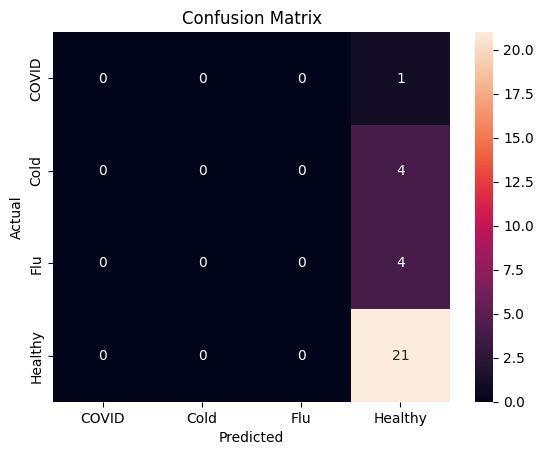

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=diseases)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=diseases, yticklabels=diseases)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [22]:
pd.DataFrame(cpt).T  # neat table view


,Fever,Cough,Fatigue,LossOfTaste
COVID,0.125000,0.125000,0.125000,0.125000
Cold,0.058824,0.058824,0.058824,0.058824
Flu,0.052632,0.052632,0.052632,0.052632
Healthy,0.011905,0.011905,0.011905,0.011905


Text(0.5, 1.0, 'Conditional Probabilities P(Symptom=Yes | Disease)')

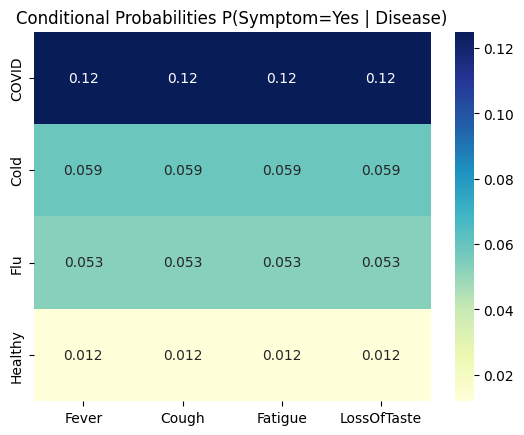

In [23]:
sns.heatmap(pd.DataFrame(cpt).T, annot=True, cmap="YlGnBu")
plt.title("Conditional Probabilities P(Symptom=Yes | Disease)")


In [24]:
# Example cases
cases = [
    {'Fever': 1, 'Cough': 1, 'Fatigue': 1, 'LossOfTaste': 1},
    {'Fever': 1, 'Cough': 0, 'Fatigue': 0, 'LossOfTaste': 0},
    {'Fever': 0, 'Cough': 1, 'Fatigue': 1, 'LossOfTaste': 0}
]

for i, e in enumerate(cases, 1):
    print(f"\n🧪 Case {i}: {e}")
    print(posterior(e, priors, cpt, diseases))



🧪 Case 1: {'Fever': 1, 'Cough': 1, 'Fatigue': 1, 'LossOfTaste': 1}
{'COVID': np.float64(0.8245517464397434), 'Cold': np.float64(0.10109325658867796), 'Flu': np.float64(0.07342790392964575), 'Healthy': np.float64(0.0009270930419329249)}

🧪 Case 2: {'Fever': 1, 'Cough': 0, 'Fatigue': 0, 'LossOfTaste': 0}
{'COVID': np.float64(0.17086517365673423), 'Cold': np.float64(0.25016333118544787), 'Flu': np.float64(0.25871413823023803), 'Healthy': np.float64(0.32025735692757984)}

🧪 Case 3: {'Fever': 0, 'Cough': 1, 'Fatigue': 1, 'LossOfTaste': 0}
{'COVID': np.float64(0.41885664927689964), 'Cold': np.float64(0.2682956124881304), 'Flu': np.float64(0.24663661970814138), 'Healthy': np.float64(0.06621111852682866)}


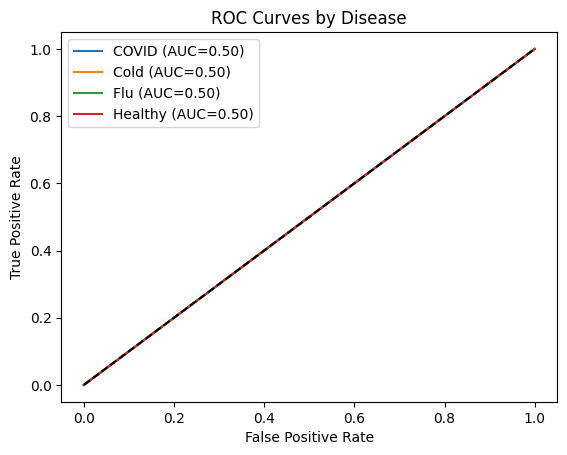

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_true, classes=diseases)
y_pred_bin = np.array(y_proba)

plt.figure()
for i, d in enumerate(diseases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    plt.plot(fpr, tpr, label=f'{d} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Disease')
plt.show()


Text(0.5, 1.0, 'Calibration Plot')

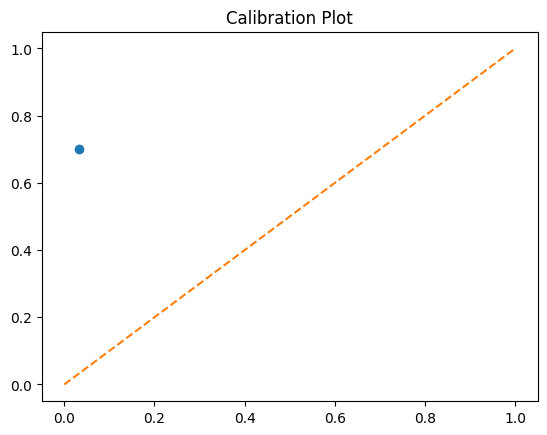

In [27]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve([d==y_true[0] for d in y_true], [p[0] for p in y_proba], n_bins=5)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title('Calibration Plot')


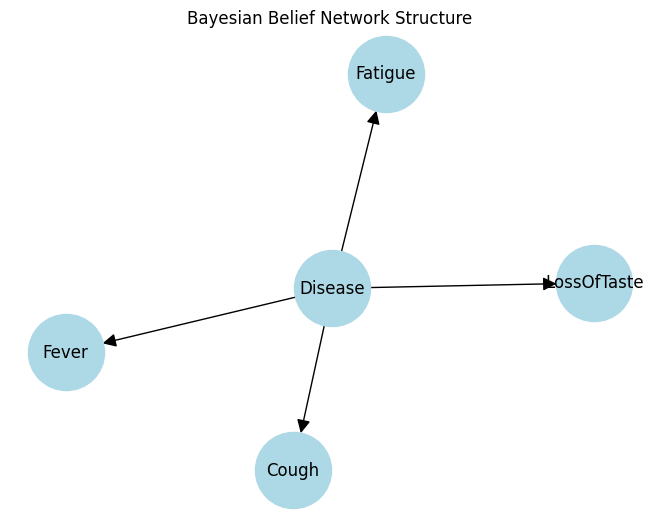

In [ ]:
import networkx as nx

G = nx.DiGraph()
G.add_node("Disease")
for s in symptoms:
    G.add_edge("Disease", s)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", arrowsize=20)
plt.title("Bayesian Belief Network Structure")
plt.show()
